In [1]:
# 🔧 DIAGNÓSTICO DE ERRO CUDA - Execute antes de treinar
import torch
import torch.cuda as cuda

print("="*80)
print("📊 DIAGNÓSTICO DO SISTEMA GPU")
print("="*80)

# Verificar GPU
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"GPU encontrada: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Nenhuma'}")

if torch.cuda.is_available():
    # Limpar cache antes de começar
    print("\n🧹 Limpando cache de GPU...")
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    
    # Informações de memória
    props = torch.cuda.get_device_properties(0)
    total_memory = props.total_memory / 1e9
    print(f"Memória total da GPU: {total_memory:.2f} GB")
    
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f"Memória alocada: {allocated:.2f} GB")
    print(f"Memória reservada: {reserved:.2f} GB")
    print(f"Memória livre: {(total_memory - reserved):.2f} GB")
    
    # Verificar compatibilidade
    print(f"\nVersão CUDA: {torch.version.cuda}")
    print(f"Versão cuDNN: {torch.backends.cudnn.version()}")
    print(f"cuDNN habilitado: {torch.backends.cudnn.enabled}")
    
else:
    print("⚠️  CUDA não disponível! Usando CPU (muito lento).")

print("="*80 + "\n")

📊 DIAGNÓSTICO DO SISTEMA GPU
CUDA disponível: False
GPU encontrada: Nenhuma
⚠️  CUDA não disponível! Usando CPU (muito lento).



/home/leo/Documents/dev/oca-ia/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:

FILE_PATH = 'norm_outros_dataset.csv'


print("Iniciando o programa...")
print("Parametros de Execucao:")
folds = 5
epochs = 50
BATCH_SIZE = 32  # ✅ REDUZIDO de 64 para 32 (evita erro CUDA)
N_samples = 2000
flg_salvar_modelos = True

print(f"  Numero de folds para K-Fold Cross Validation: {folds}")

print(f"  Tamanho do batch para treinamento: {BATCH_SIZE}")

print(f"  Numero de epocas para treinamento: {epochs}")


Iniciando o programa...
Parametros de Execucao:
  Numero de folds para K-Fold Cross Validation: 5
  Tamanho do batch para treinamento: 32
  Numero de epocas para treinamento: 50


In [3]:
!pip install -r requirements.txt 


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import pandas as pd
from PIL import Image, ImageChops
import numpy as np
import torch
from lib.ImageFIlter import treat_image_PIL
from sklearn.model_selection import KFold
from torch.utils.data import  DataLoader, TensorDataset, Dataset
from torch import nn
import timm
from tqdm.notebook import tqdm
import torch.optim as optim
import os

## Funcao de filtro de imagem

In [5]:
from PIL import Image, ImageChops
import numpy as np
import os
import shutil
import io
from pathlib import Path
path = '/home/leo/Documents/ecg_classifier/dataset/database_ptbxl/'
def treat_image_PIL(img_path, type_return=2):
    ''''
    Input: Img_path, type return.

    Img_path: path da imagem em formato png, img...
    type_return: 1-> retorno como PIL. 
                2 ou sem type_return -> retorno como numpy array tipo uint8

    Output:
    '''
    im = Image.open(path+img_path) 
    
    # Size of the image in pixels (size of original image) 
    # (This is not mandatory) 
    width, height = im.size 

    rgb =Image.Image.split(im) 

    data =rgb
    b= data[0]
    g= data[1]
    r= data[2]
    #img_out = b+g+.5*r
    #img_out_2 = img_out[500:1600, 50:2100] 

    newsize = (256, 256)
   # im3 =ImageChops.subtract(mask,b, scale=1.0, offset=0)

    b1 = b.crop((120,500,2100,1600))
    g1 = g.crop((120,500,2100,1600))
    r1 = r.crop((120,500,2100,1600))
    im1 = b1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    im2 = g1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    im3 = r1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    if type_return ==1:
        return Image.merge("RGB",(im1,im1,im1))
    else:
        return np.array([im1,im1,im1],dtype=np.uint8)


def save_file_to_dir(file_obj, directory, filename):
    """
    Save a file to `directory` with the given `filename`.

    Parameters
    - file_obj: a PIL Image, a filesystem path (str or Path) to an existing file,
                bytes/bytearray, or a file-like object with a .read() method.
    - directory: target directory where the file will be saved.
    - filename: the name to use for the saved file (including extension if desired).

    Returns
    - full path (str) to the saved file.

    Raises
    - FileNotFoundError if a provided source path does not exist.
    - ValueError if the provided file_obj type is unsupported.
    """
    os.makedirs(directory, exist_ok=True)
    dest = os.path.join(directory, filename)

    # PIL Image
    if isinstance(file_obj, Image.Image):
        file_obj.save(dest)
        return dest

    # Path-like or string pointing to an existing file
    if isinstance(file_obj, (str, Path)):
        src = str(file_obj)
        if os.path.exists(src):
            shutil.copy(src, dest)
            return dest
        raise FileNotFoundError(f"Source path not found: {src}")

    # File-like object
    if hasattr(file_obj, "read"):
        data = file_obj.read()
        # If read() returned bytes -> try open as image, otherwise write raw
        if isinstance(data, (bytes, bytearray)):
            try:
                img = Image.open(io.BytesIO(data))
                img.save(dest)
                return dest
            except Exception:
                with open(dest, "wb") as f:
                    f.write(data)
                return dest
        else:
            # assume text
            with open(dest, "w", encoding="utf-8") as f:
                f.write(data)
            return dest

    # Raw bytes
    if isinstance(file_obj, (bytes, bytearray)):
        try:
            img = Image.open(io.BytesIO(file_obj))
            img.save(dest)
            return dest
        except Exception:
            with open(dest, "wb") as f:
                f.write(file_obj)
            return dest

    raise ValueError("file_obj must be a PIL.Image, path string/Path, bytes or file-like object")

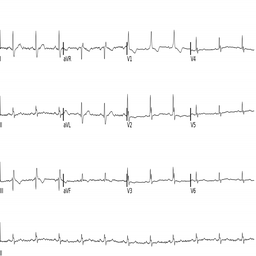

In [6]:
## Exemplo de uso de resize de imagem 
path = '/home/leo/Documents/ecg_classifier/dataset/database_ptbxl/' 
image  = treat_image_PIL('12415_lr-0.png',1)
display(image)

## Funcoes output_metricas

In [7]:
import os
## Cria funcao para validar se pasta a ser inserida existe. Caso nao exista, cria a pasta
def create_folder_if_not_exists(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f'Pasta {folder_path} criada.')
    else:
        print(f'Pasta {folder_path} ja existe.')


## Funcoes subset

In [8]:
from torch.utils.data import  Dataset

class Subset(Dataset):
    r"""
    Subset of a dataset at specified indices.

    Arguments:
        dataset (Dataset): The whole Dataset
        indices (sequence): Indices in the whole set selected for subset
    """
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]

    def __len__(self):
        return len(self.indices)

    @property
    def classes(self):
        return self.data.classes

    def shape(self):
        return self.dataset

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: " + str(device))

Device: cpu


## Funcoes simple_loop

In [ ]:
import torch
from torch import nn
import numpy as np
import os
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch.cuda.amp import autocast, GradScaler

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: " + str(device))

class EarlyStopping:
    """
    Classe para implementar Early Stopping no treinamento.
    Para o treinamento quando a validation loss não melhora após 'patience' épocas.
    
    Parâmetros:
        patience (int): Número de épocas sem melhora antes de parar (default: 5)
        delta (float): Threshold mínimo de melhora (default: 0.001)
        save_best_model (bool): Se deve salvar o melhor modelo (default: True)
    """
    def __init__(self, patience=10, delta=0.001, save_best_model=True):
        self.patience = patience
        self.delta = delta
        self.save_best_model = save_best_model
        self.counter = 0
        self.best_val_loss = None
        self.early_stop_flag = False
        self.best_model_state = None
        
    def __call__(self, val_loss, model, fold_index):
        """
        Valida se deve parar o treinamento.
        
        Parâmetros:
            val_loss (float): Validation loss da época atual
            model: Modelo sendo treinado
            fold_index (int): Índice do fold (para nomear o arquivo do melhor modelo)
            
        Retorna:
            bool: True se deve parar o treinamento, False caso contrário
        """
        if self.best_val_loss is None:
            self.best_val_loss = val_loss
            if self.save_best_model:
                self.best_model_state = model.state_dict().copy()
        elif val_loss < self.best_val_loss - self.delta:
            # Houve melhora significativa
            self.best_val_loss = val_loss
            self.counter = 0
            if self.save_best_model:
                self.best_model_state = model.state_dict().copy()
                print(f'✓ Validation loss melhorou para {val_loss:.6f}. Melhor modelo salvo.')
        else:
            # Sem melhora significativa
            self.counter += 1
            print(f'⚠ Sem melhora por {self.counter}/{self.patience} épocas. Validation loss atual: {val_loss:.6f}')
            if self.counter >= self.patience:
                self.early_stop_flag = True
                print(f'🛑 Early Stopping ativado após {self.counter} épocas sem melhora!')
                if self.save_best_model and self.best_model_state is not None:
                    # Restaura o melhor modelo
                    model.load_state_dict(self.best_model_state)
                    print(f'✓ Melhor modelo restaurado com validation loss: {self.best_val_loss:.6f}')
                return True
        return False
    
    def reset(self):
        """Reseta o Early Stopping para um novo fold."""
        self.counter = 0
        self.best_val_loss = None
        self.early_stop_flag = False
        self.best_model_state = None

def salvar_model(model, path = 'output/modelos', name_file='model.pth'):
    create_folder_if_not_exists(path)

    full_path = os.path.join(path, name_file)
    torch.save(model.state_dict(), full_path)

def salvar_metricas(path, name_file_train='train_loss_total.npy', name_file_val='val_loss_total.npy',predict_label=None, true_label=None):
    create_folder_if_not_exists(path)
    full_path_train = os.path.join(path, name_file_train)
    full_path_val = os.path.join(path, name_file_val)
    np.save(full_path_train, np.array(predict_label))
    np.save(full_path_val, np.array(true_label))
    print(f'Metricas salvas em {path} com os nomes {name_file_train} e {name_file_val} e tamanhos {np.array(predict_label).shape} e {np.array(true_label).shape}')

def simple_loop(model, train_image, val_image, epochs, batch_size, fold_index, patience=10, delta=0.001, device_input=None):
    """
    Loop de treinamento e validação com Early Stopping, regularização e monitoramento de métricas.
    ✅ MELHORIAS: Mixed Precision, detecção CUDA, garantir float32, device handling
    
    Parâmetros adicionais:
        patience (int): Número de épocas sem melhora antes de parar (default: 10)
        delta (float): Threshold mínimo de melhora para considerar como melhora (default: 0.001)
        device_input: torch.device('cuda:0') ou torch.device('cpu')
    """
    # Use device global se não fornecido
    if device_input is None:
        device_input = device
    
    # Simple training loop
    num_epochs = epochs
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_f1s, val_f1s = [], []
    lim_loss = 1.5
    iter_size = batch_size
    print(f'Number of training images per iteration: {iter_size}')
    print(f'Device sendo usado: {device_input}')
    
    # ✅ IMPORTANTE: Move model para device PRIMEIRO
    try:
        #model = model.to(device_input)
        print(f'✓ Modelo movido para {device_input}')
    except Exception as e:
        print(f'❌ ERRO ao mover modelo para device: {e}')
        raise
    
    # ✅ FIX: Usar mixed precision para reduzir uso de memória
    scaler = GradScaler()
    use_amp = False
    print(f'Mixed Precision (AMP) habilitado: {use_amp}')
    
    criterion = nn.CrossEntropyLoss()
    # Optimizer COM regularização (weight_decay)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    predict_label_full_train = []
    predict_label_full = []
    true_label_full_train = []
    true_label_full = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        predict_label_train = []
        true_label_train = []
        running_loss_train = 0.0
        
        try:
            for images, labels in tqdm(train_image, desc='Training loop'):
                # ✅ FIX: Garantir float32 e evitar overflow
                images = images.to(torch.float32)
                labels = labels.to(torch.long)
                
                optimizer.zero_grad()
                
                # ✅ FIX: Usar autocast para mixed precision
                if use_amp:
                    with autocast(dtype=torch.float16):
                        outputs = model(images)
                        _true = labels.squeeze()
                        loss_train = criterion(outputs.to(torch.float32), _true)
                    scaler.scale(loss_train).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Clip gradientes
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    outputs = model(images)
                    _true = labels.squeeze()
                    loss_train = criterion(outputs.to(torch.float32), _true)
                    loss_train.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                
                _pred_train = torch.argmax(outputs, dim=1)
                running_loss_train += loss_train.item() * labels.size(0)
                
                # Salvar predições e labels CORRETAMENTE
                try:
                    pred_list = _pred_train.cpu().detach().numpy().astype(int).tolist()
                    true_list = labels.squeeze().cpu().detach().numpy().astype(int).tolist()
                    
                    if not isinstance(pred_list, list):
                        pred_list = [pred_list]
                    if not isinstance(true_list, list):
                        true_list = [true_list]
                    
                    if len(pred_list) == iter_size:
                        predict_label_train.append(pred_list)
                        true_label_train.append(true_list)
                        
                except Exception as e:
                    print(f"⚠ Erro ao salvar predições de treinamento: {e}")
        
        except RuntimeError as e:
            if "CUDA" in str(e) or "assert" in str(e).lower():
                print(f"\n❌ ERRO CUDA durante treinamento: {e}")
                print("💡 Sugestões:")
                print("   1. Reduza BATCH_SIZE")
                print("   2. Execute torch.cuda.empty_cache()")
                print("   3. Use modelos menores")
                torch.cuda.empty_cache()
                raise
            else:
                raise
        
        train_loss = running_loss_train / len(train_image.dataset)
        train_losses.append(train_loss)
        
        # Calcular métricas de treinamento
        try:
            if predict_label_train and true_label_train:
                train_preds = np.concatenate(predict_label_train)
                train_trues = np.concatenate(true_label_train)
                train_acc = accuracy_score(train_trues, train_preds)
                train_f1 = f1_score(train_trues, train_preds, average='weighted', zero_division=0)
                train_accuracies.append(train_acc)
                train_f1s.append(train_f1)
        except Exception as e:
            print(f"⚠ Erro ao calcular métricas de treinamento: {e}")
        
        try:
            _p_train = predict_label_train
            _t_train = true_label_train
            predict_label_full_train.append(_p_train)
            true_label_full_train.append(_t_train)
        except Exception as e:
            print(f"⚠ Erro ao concatenar métricas de treinamento: {e}")
        
        # Validation phase
        model.eval()
        running_loss_valid = 0.0
        predict_label = []
        true_label = []
        _iter = 0
        
        try:
            with torch.no_grad():
                for images, labels in tqdm(val_image, desc='Validation loop'):
                    # ✅ FIX: Garantir float32
                    images = images.to(torch.float32)
                    labels = labels.to(torch.long)
                    
                    if use_amp:
                        with autocast(dtype=torch.float16):
                            outputs = model(images)
                    else:
                        outputs = model(images)
                    
                    loss_valid = criterion(outputs.to(torch.float32), labels.squeeze())
                    
                    # Get predictions
                    _pred = torch.argmax(outputs, dim=1)
                    
                    # Salvar predições e labels
                    try:
                        pred_list = _pred.cpu().numpy().astype(int).tolist()
                        true_list = labels.squeeze().cpu().numpy().astype(int).tolist()
                        
                        if not isinstance(pred_list, list):
                            pred_list = [pred_list]
                        if not isinstance(true_list, list):
                            true_list = [true_list]
                        
                        if len(pred_list) == iter_size:
                            predict_label.append(pred_list)
                            true_label.append(true_list)
                            
                    except Exception as e:
                        print(f"⚠ Erro ao salvar predições de validação: {e}")
                    
                    running_loss_valid += loss_valid.item() * labels.size(0)
                    _iter += 1
        
        except RuntimeError as e:
            if "CUDA" in str(e) or "assert" in str(e).lower():
                print(f"\n❌ ERRO CUDA durante validação: {e}")
                torch.cuda.empty_cache()
                raise
            else:
                raise
        
        val_loss = running_loss_valid / len(val_image.dataset)
        val_losses.append(val_loss)
        
        # Calcular métricas de validação
        val_precision = 0
        val_recall = 0
        try:
            if predict_label and true_label:
                val_preds = np.concatenate(predict_label)
                val_trues = np.concatenate(true_label)
                val_acc = accuracy_score(val_trues, val_preds)
                val_f1 = f1_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_precision = precision_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_recall = recall_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_accuracies.append(val_acc)
                val_f1s.append(val_f1)
        except Exception as e:
            print(f"⚠ Erro ao calcular métricas de validação: {e}")
        
        try:
            _p = predict_label
            _t = true_label
            predict_label_full.append(_p)
            true_label_full.append(_t)
        except Exception as e:
            print(f"⚠ Erro ao concatenar métricas de validação: {e}")
        
        # Print detalhado das métricas
        print(f"\n{'='*80}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*80}")
        print(f"Train Loss: {train_loss:.6f}", end="")
        if train_accuracies:
            print(f" | Train Acc: {train_accuracies[-1]:.4f}", end="")
            print(f" | Train F1: {train_f1s[-1]:.4f}", end="")
        print()
        print(f"Val Loss:   {val_loss:.6f}", end="")
        if val_accuracies:
            print(f" | Val Acc: {val_accuracies[-1]:.4f}", end="")
            print(f" | Val F1: {val_f1s[-1]:.4f}", end="")
            print(f" | Precision: {val_precision:.4f}", end="")
            print(f" | Recall: {val_recall:.4f}", end="")
        print()
        print(f"{'='*80}\n")

    predict_label_full_out = np.array(predict_label_full, dtype=object)
    true_label_full_out = np.array(true_label_full, dtype=object)
    predict_label_full_train_out = np.array(predict_label_full_train, dtype=object)
    true_label_full_train_out = np.array(true_label_full_train, dtype=object)
    print(f'Salvado das metricas de validacao e treino')
    
    salvar_metricas(path=f'output/metricas/valid/fold_{fold_index}', 
                    name_file_train=f'predict_label_valid_fold_{fold_index}.npy', 
                    name_file_val=f'true_label_valid_fold_{fold_index}.npy', 
                    predict_label= predict_label_full_out, true_label= true_label_full_out)
    
    salvar_metricas(path=f'output/metricas/train/fold_{fold_index}', 
                    name_file_train=f'predict_label_train_fold_{fold_index}.npy', 
                    name_file_val=f'true_label_train_fold_{fold_index}.npy', 
                    predict_label= predict_label_full_train_out, true_label= true_label_full_train_out)
    print(f'Finalizado o salvamento das metricas')
    return train_losses, val_losses, model, predict_label_full_out, true_label_full_out

Device: cpu


## Funcao Modelo ECG Resnet

In [11]:
#from models import ECGClassifierResnet
from torch import nn
import timm
class ECGClassifierResnet(nn.Module):
    def __init__(self, num_classes=1):
        super(ECGClassifierResnet, self).__init__()
        # Where we define all the parts of the model
        #self.base_model = timm.create_model('efficientnet_b0', pretrained=True) 
        self.base_model=timm.create_model('resnet50d.ra4_e3600_r224_in1k',pretrained=True)
        #self.base_model = timm.create_model('vit_mediumd_patch16_reg4_gap_256.sbb2_e200_in12k_ft_in1k',num_classes=5,pretrained=True)

        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 2048        # Make a classifier
        # For binary classification com Dropout para regularização
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),           # Dropout para regularização (reduz overfitting)
            nn.ReLU(),
            nn.Dropout(0.3),           # Dropout adicional antes da saída
            nn.Linear(enet_out_size, 2)
        ) # saida como Softmax para classificacao single label

    def forward(self, x):
        # Connect these parts and return the output
        x = self.features(x)
        output = self.classifier(x)
        #output = nn.Softmax(dim=1)(output)
        return output


In [12]:
## Efficient net b0 
from torch import nn
import timm
class ECGClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes=1):
        super(ECGClassifierEfficientNet, self).__init__()
        # Where we define all the parts of the model
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True) 
        #self.base_model=timm.create_model('resnet50d.ra4_e3600_r224_in1k',pretrained=True)
        #self.base_model = timm.create_model('vit_mediumd_patch16_reg4_gap_256.sbb2_e200_in12k_ft_in1k',num_classes=5,pretrained=True)

        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 1280        # Make a classifier
        # For binary classification we output a single logit and use BCEWithLogitsLoss
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.ReLU(),
            nn.Linear(enet_out_size,1)
        ) # saida como Softmax para classificacao single label
        #self.classifier = nn.Sequential(
        #    nn.Flatten(),
        #    nn.Linear(enet_out_size,1)
        #) # saida como Sigmoid multilabel  

    def forward(self, x):
        # Connect these parts and return the output
        x = self.features(x)
        output = self.classifier(x)
        #output = nn.Softmax(dim=1)(output)
        return output

## Arquivo Main.py - Orquestrador

In [13]:
class BinaryClassifier256x256(nn.Module):
    """
    Classificador binário com entrada 256x256 e aproximadamente 200 mil parâmetros.
    Saída: 2 neurônios lineares (logits para as 2 classes)
    """
    
    def __init__(self):
        super(BinaryClassifier256x256, self).__init__()
        
        # Dimensões
        
        # Dimensões para entrada RGB 256x256 com 3 canais
        self.input_size = 3 * 256 * 256  # 196608 (RGB)        
        # Bloco 1: reduz dimensionalidade
        self.fc1 = nn.Linear(self.input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.5)
        
        # Bloco 2: 512 → 256
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.4)
        
        # Bloco 3: 256 → 128
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout3 = nn.Dropout(0.3)
        
        # Bloco 4: 128 → 64
        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        self.dropout4 = nn.Dropout(0.2)
        
        # Saída: 64 → 2
        self.fc_out = nn.Linear(64, 2)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        """Forward pass"""
        # Flatten: (batch, 3, 256, 256) → (batch, 196608)
        x = x.view(x.size(0), -1)
        
        # Bloco 1
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        
        # Bloco 2
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        
        # Bloco 3
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        
        # Bloco 4
        x = self.relu(self.bn4(self.fc4(x)))
        x = self.dropout4(x)
        
        # Saída
        x = self.fc_out(x)
        return x

### Geracao do tensor

#### Load Images

In [14]:
## Funções Otimizadas para Leitura de CSV e Carregamento de Imagens

import os
import psutil
from pathlib import Path

def explore_csv(csv_path, max_rows=5):
    """
    Explora arquivo CSV fornecendo informações detalhadas.
    
    Parâmetros:
        csv_path (str): Caminho do arquivo CSV
        max_rows (int): Número de linhas para exibir
    
    Retorna:
        pd.DataFrame: Dados carregados
    """
    print("="*80)
    print("📋 EXPLORAÇÃO DO ARQUIVO CSV")
    print("="*80)
    
    # Verificar se arquivo existe
    if not os.path.exists(csv_path):
        print(f"❌ ERRO: Arquivo não encontrado: {csv_path}")
        return None
    
    print(f"✓ Arquivo encontrado: {csv_path}")
    print(f"  Tamanho do arquivo: {os.path.getsize(csv_path) / (1024*1024):.2f} MB")
    
    try:
        # Ler CSV
        print("\n📖 Lendo arquivo CSV...")
        data = pd.read_csv(csv_path)
        
        print(f"✓ CSV lido com sucesso!")
        print(f"  Shape: {data.shape} (linhas, colunas)")
        print(f"  Colunas: {list(data.columns)}")
        print(f"  Tipos de dados:\n{data.dtypes}\n")
        
        # Verificar valores nulos
        print("📊 Valores Nulos:")
        null_counts = data.isnull().sum()
        if null_counts.sum() == 0:
            print("  ✓ Nenhum valor nulo encontrado!")
        else:
            print(f"  ⚠ Valores nulos encontrados:\n{null_counts}\n")
        
        # Primeiras linhas
        print(f"📄 Primeiras {max_rows} linhas:")
        print(data.head(max_rows).to_string())
        
        # Estatísticas
        print(f"\n📈 Estatísticas básicas:")
        print(f"  Total de amostras: {len(data)}")
        if data.shape[1] >= 2:
            label_col = data.columns[1]
            print(f"  Distribuição de labels ({label_col}):")
            print(data[label_col].value_counts().to_string())
        
        print("="*80)
        return data
        
    except Exception as e:
        print(f"❌ ERRO ao ler CSV: {e}")
        return None


def validate_and_load_images(data, image_path_prefix, n_samples=None, max_errors=10):
    """
    Valida e carrega imagens com tratamento robusto de erros.
    
    Parâmetros:
        data (pd.DataFrame): DataFrame com caminhos das imagens
        image_path_prefix (str): Prefixo do caminho das imagens
        n_samples (int): Número de amostras a carregar (None = todas)
        max_errors (int): Máximo de erros antes de parar
    
    Retorna:
        tuple: (img_dataset, data_valid, error_count)
    """
    print("\n" + "="*80)
    print("🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS")
    print("="*80)
    
    # Preparar dados
    if n_samples is not None:
        data_sample = data.sample(n=min(n_samples, len(data)), random_state=42).reset_index(drop=True)
    else:
        data_sample = data.reset_index(drop=True)
    
    print(f"\n📌 Configuração:")
    print(f"  Amostras a processar: {len(data_sample)}")
    print(f"  Prefixo de caminho: {image_path_prefix}")
    print(f"  Máximo de erros permitidos: {max_errors}")
    
    # Verificar memória disponível
    memory_info = psutil.virtual_memory()
    print(f"\n💾 Memória disponível: {memory_info.available / (1024**3):.2f} GB")
    estimated_memory = (len(data_sample) * 3 * 256 * 256 * 1) / (1024**3)
    print(f"  Memória estimada para imagens: {estimated_memory:.2f} GB")
    
    if estimated_memory > memory_info.available * 0.8:
        print(f"  ⚠ AVISO: Uso de memória pode ser alto!")
    
    # Preparar array
    img_dataset = np.zeros((len(data_sample), 3, 256, 256), dtype=np.uint8)
    error_indices = []
    error_count = 0
    
    print(f"\n🔄 Carregando imagens...")
    
    for idx, row in tqdm(data_sample.iterrows(), total=len(data_sample), desc='Carregando imagens'):
        try:
            img_path = row.iloc[0]  # Primeira coluna = caminho
            full_path = os.path.join(image_path_prefix, img_path)
            
            # Verificar se arquivo existe
            if not os.path.exists(full_path):
                raise FileNotFoundError(f"Imagem não encontrada: {full_path}")
            
            # Carregar imagem
            img = treat_image_PIL(img_path, type_return=2)
            
            # Validar shape
            if img.shape != (3, 256, 256):
                raise ValueError(f"Shape inesperado: {img.shape}, esperado (3, 256, 256)")
            
            img_dataset[idx] = img
            
        except Exception as e:
            error_count += 1
            error_indices.append(idx)
            
            if error_count == 1:
                print(f"\n⚠ Erros encontrados durante carregamento:")
            
            print(f"  Erro na amostra {idx}: {type(e).__name__}: {str(e)[:60]}")
            
            if error_count >= max_errors:
                print(f"\n❌ Máximo de {max_errors} erros atingido. Parando...")
                break
    
    # Remover amostras com erro
    if error_indices:
        print(f"\n🧹 Removendo {len(error_indices)} amostras com erro...")
        valid_indices = [i for i in range(len(data_sample)) if i not in error_indices]
        img_dataset = img_dataset[valid_indices]
        data_sample = data_sample.iloc[valid_indices].reset_index(drop=True)
    
    print("\n✅ Carregamento concluído!")
    print(f"  Imagens carregadas com sucesso: {len(img_dataset)}")
    print(f"  Imagens com erro: {error_count}")
    print(f"  Shape final: {img_dataset.shape}")
    print("="*80)
    
    return img_dataset, data_sample, error_count


def get_image_statistics(img_dataset):
    """Calcula estatísticas das imagens carregadas."""
    print("\n" + "="*80)
    print("📊 ESTATÍSTICAS DAS IMAGENS")
    print("="*80)
    
    print(f"Shape: {img_dataset.shape}")
    print(f"Tipo de dado: {img_dataset.dtype}")
    print(f"Min: {img_dataset.min()}")
    print(f"Max: {img_dataset.max()}")
    print(f"Média: {img_dataset.mean():.2f}")
    print(f"Std: {img_dataset.std():.2f}")
    print(f"Memória total: {img_dataset.nbytes / (1024**2):.2f} MB")
    print("="*80)


In [15]:
print(f"Leitura e carregamento otimizado do arquivo '{FILE_PATH}'...\n")

# 1️⃣ EXPLORAR CSV PRIMEIRO
data = explore_csv(FILE_PATH, max_rows=10)

if data is None:
    print("❌ Não foi possível continuar. Verifique o arquivo CSV.")
else:
    # 2️⃣ RENOMEAR COLUNAS PARA PADRONIZAÇÃO
    print("\n🏷️  Padronizando nomes de colunas...")
    if data.shape[1] >= 2:
        data.rename(columns={data.columns[0]: 'path', data.columns[1]: 'label'}, inplace=True)
        print(f"✓ Colunas renomeadas: {list(data.columns[:2])}\n")
    
    # 3️⃣ CARREGAR IMAGENS COM VALIDAÇÃO
    img_dataset, data, error_count = validate_and_load_images(
        data=data,
        image_path_prefix=path,  # path definido anteriormente
        n_samples=N_samples,
        max_errors=10
    )
    
    # 4️⃣ ESTATÍSTICAS DAS IMAGENS
    get_image_statistics(img_dataset)
    
    # 5️⃣ RESUMO FINAL
    print("\n" + "="*80)
    print("✅ RESUMO FINAL DO CARREGAMENTO")
    print("="*80)
    print(f"Arquivo CSV: {FILE_PATH}")
    print(f"Total de amostras: {len(data)}")
    print(f"Shape de imagens: {img_dataset.shape}")
    print(f"Distribuição de labels:")
    print(data['label'].value_counts().to_string())
    print("="*80 + "\n")


Leitura e carregamento otimizado do arquivo 'norm_outros_dataset.csv'...

📋 EXPLORAÇÃO DO ARQUIVO CSV
✓ Arquivo encontrado: norm_outros_dataset.csv
  Tamanho do arquivo: 0.34 MB

📖 Lendo arquivo CSV...
✓ CSV lido com sucesso!
  Shape: (20780, 2) (linhas, colunas)
  Colunas: ['filename_lr', 'macro_class']
  Tipos de dados:
filename_lr      str
macro_class    int64
dtype: object

📊 Valores Nulos:
  ✓ Nenhum valor nulo encontrado!
📄 Primeiras 10 linhas:
      filename_lr  macro_class
0  00001_lr-0.png            1
1  00002_lr-0.png            1
2  00003_lr-0.png            1
3  00004_lr-0.png            1
4  00005_lr-0.png            1
5  00006_lr-0.png            1
6  00007_lr-0.png            1
7  00008_lr-0.png            0
8  00009_lr-0.png            1
9  00010_lr-0.png            1

📈 Estatísticas básicas:
  Total de amostras: 20780
  Distribuição de labels (macro_class):
macro_class
0    11586
1     9194

🏷️  Padronizando nomes de colunas...
✓ Colunas renomeadas: ['path', 'label']


Carregando imagens:   0%|          | 0/2000 [00:00<?, ?it/s]

Carregando imagens: 100%|██████████| 2000/2000 [01:41<00:00, 19.75it/s]



✅ Carregamento concluído!
  Imagens carregadas com sucesso: 2000
  Imagens com erro: 0
  Shape final: (2000, 3, 256, 256)

📊 ESTATÍSTICAS DAS IMAGENS
Shape: (2000, 3, 256, 256)
Tipo de dado: uint8
Min: 0
Max: 255
Média: 249.77
Std: 19.62
Memória total: 375.00 MB

✅ RESUMO FINAL DO CARREGAMENTO
Arquivo CSV: norm_outros_dataset.csv
Total de amostras: 2000
Shape de imagens: (2000, 3, 256, 256)
Distribuição de labels:
label
0    1076
1     924



#### Data Augumentation

In [16]:
## Data Augmentation Expandida - Compose com v2.Compose para numpy arrays (3, 256, 256)

from torchvision.transforms import v2

# Define as transformações usando v2 (Expandidas para melhor regularização e generalização)
transforms = v2.Compose([
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=30),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # Zoom e translação
    v2.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),                    # Blur
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),        # Variações de cor
    v2.RandomPerspective(distortion_scale=0.2, p=0.3),                   # Perspectiva
])

# Aplica transformações a todo o dataset
print("Aplicando augmentação expandida com v2.Compose...")
img_dataset_aug = np.zeros_like(img_dataset, dtype=np.uint8)
for i in tqdm(range(len(img_dataset)), desc='Applying augmentation'):
    # Aplica transformações via PIL
    img_pil = Image.fromarray(img_dataset[i].transpose(1, 2, 0).astype('uint8'), 'RGB')
    img_transformed = transforms(img_pil)
    img_dataset_aug[i] = np.array(img_transformed).transpose(2, 0, 1)


Aplicando augmentação expandida com v2.Compose...


Applying augmentation:   0%|          | 0/2000 [00:00<?, ?it/s]

Applying augmentation: 100%|██████████| 2000/2000 [00:06<00:00, 332.10it/s]


In [17]:
tensor_imagem = torch.from_numpy(img_dataset_aug)

Imagem Original:


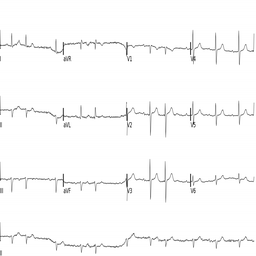

Imagem Transformada:


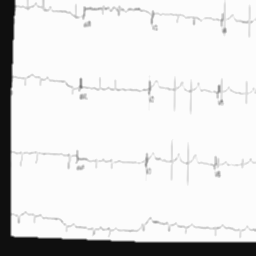

Imagem Original:


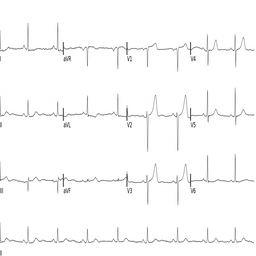

Imagem Transformada:


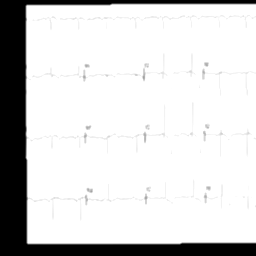

Imagem Original:


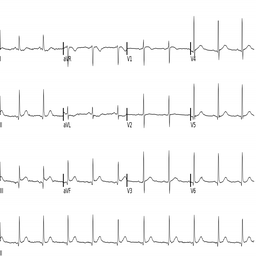

Imagem Transformada:


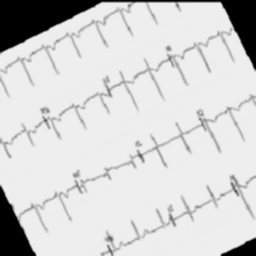

Imagem Original:


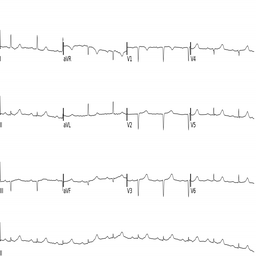

Imagem Transformada:


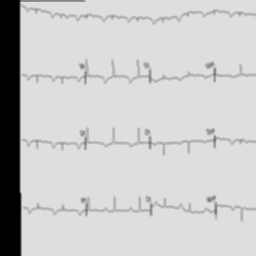

Imagem Original:


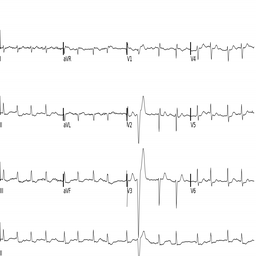

Imagem Transformada:


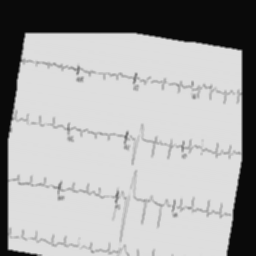

In [18]:
## crie uma transformacao de numpy para image pil e faca o display da imagem original e da imagem transformada para verificar se a transformacao esta correta
def numpy_to_pil(numpy_array):
    # Verifica se o array tem a forma correta (C, H, W)
    if numpy_array.shape[0] != 3:
        raise ValueError("O array deve ter a forma (3, H, W) para ser convertido em imagem PIL.")
    
    # Transpõe o array para a forma (H, W, C)
    numpy_array = np.transpose(numpy_array, (1, 2, 0))
    
    # Converte o array para uma imagem PIL
    pil_image = Image.fromarray(numpy_array.astype('uint8'), 'RGB')
    
    return pil_image
for i in range(5):
    original_image = numpy_to_pil(img_dataset[i])
    transformed_image = numpy_to_pil(img_dataset_aug[i])
    print("Imagem Original:")
    display(original_image)
    print("Imagem Transformada:")
    display(transformed_image)


In [19]:
len(tensor_imagem)

2000

In [20]:
tensor_label = torch.tensor(data['label'].values)
data_tensor = TensorDataset(tensor_imagem, tensor_label)
print("Dataset de dados (imagens + labels) criado com sucesso. Tamanho do Dataset:", len(data_tensor))

Dataset de dados (imagens + labels) criado com sucesso. Tamanho do Dataset: 2000


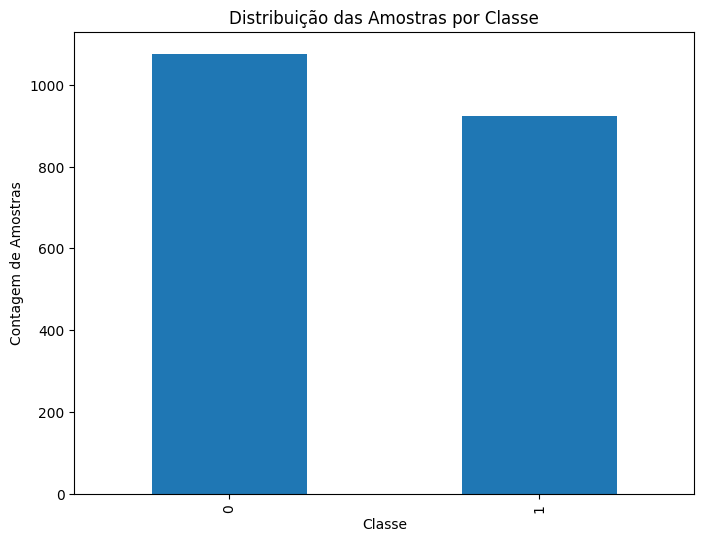

In [21]:
## Distribuicao das amostras
## Histograma da distribuicao das amostras
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))  
data['label'].value_counts().plot(kind='bar')
plt.title('Distribuição das Amostras por Classe')
plt.xlabel('Classe')
plt.ylabel('Contagem de Amostras')
plt.show()

### Geracao de rótulos para classificação

Colunas utilizadas para classificacao (Labels)

labels = [ OCA, NOCA]

In [22]:

print("Tensor de Rotulos sendo gerado...")


tensor_label = torch.tensor(np.array(data['label'].astype("float32"))).unsqueeze(1)
print("Tensor de Rotulos gerado com sucesso. Tamanho do Tensor:", tensor_label.shape)

print(f"Configuracao do K-Fold para {folds} folds...")
kf = KFold(n_splits=folds)
kf.get_n_splits(tensor_imagem)
print(kf)
print("K-Fold configurado com sucesso.")

print("Iniciando o treinamento com K-Fold Cross Validation...")

train_loss_total = []
val_loss_total =[]
all_models =[]

train_dataset = TensorDataset(tensor_imagem, tensor_label)


Tensor de Rotulos sendo gerado...
Tensor de Rotulos gerado com sucesso. Tamanho do Tensor: torch.Size([2000, 1])
Configuracao do K-Fold para 5 folds...
KFold(n_splits=5, random_state=None, shuffle=False)
K-Fold configurado com sucesso.
Iniciando o treinamento com K-Fold Cross Validation...


## Train - Valid Loop

Fluxo de treinamento

Input: modelo, dataloader_train, dataloader_teste , epocas.
- Para cada epoca

    - treinamento:

        - para cada batch (lote de imagens) no dataloader_train: (executo para todo o dataloader)
            
            leitura das imagens e rotulos. 
            
            prediz o rotulo (outputs): rotulos preditos para o tamanho do batch (ex: para um batch de 10, o 
            output tem tamanho 10)
            
            calcula o Loss () 
            
            aplica o backward -> Ajuste dos pesos nos neuronios de acordo com o valor de loss (w_{i})

            otimizo o modelo com optimizer.step()

    - validacao (avaliacao do desempenho para aquele conjunto de treinamento):
        - para cada batch (lote de imagens) no dataloader_train: (executo para todo o dataloader)

            leitura das imagens e rotulos.

            prediz o rotulo (outputs): rotulos preditos para o tamanho do batch (ex: para um batch de 10, o 
            output tem tamanho 10)
            
            calcula o Loss ()


    - Calculo de metricas de loss media de validacao.

    - Calculo de metrica de loss media de treinamento. 

    - Print de metricas de desempenho para a epoca. 








In [23]:
print('''
      ###############################################
      Inicio do treinamento com K-Fold Cross Validation
      ###############################################
      ''')
device = 'cuda:0'
    

for i, (train_index, test_index) in enumerate(kf.split(train_dataset)):
    print(f"Fold {i}:")
    #print(f"  Train: index={train_index}")
    #print(f"  Test:  index={test_index}")
    ## init train test for folder
    train_dataset_part = Subset( train_dataset, train_index)
    val_dataset_part = Subset( train_dataset, test_index)

    train_loader_img = DataLoader(train_dataset_part, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_img = DataLoader(val_dataset_part, batch_size=BATCH_SIZE, shuffle=True)

    model= BinaryClassifier256x256()
    if (flg_salvar_modelos):
        salvar_model(model, path='output/modelos', name_file=f'model_fold_{i}.pth')
    print(f'Train and valid for Fold {i}')
    # Treina com Early Stopping (patience=5 épocas, delta=0.001)
    t, l,_,outputs,labels = simple_loop(model, train_loader_img, val_loader_img, epochs, batch_size=BATCH_SIZE, fold_index=i, patience=5, delta=0.0001)
    ## Evaluate model.
    train_loss_total.append(t)
    val_loss_total.append(l)

print('''
      ###############################################
      Fim do treinamento com K-Fold Cross Validation
      ###############################################
      ''')
print("Treinamento com K-Fold Cross Validation concluído com sucesso.")


      ###############################################
      Inicio do treinamento com K-Fold Cross Validation
      ###############################################
      
Fold 0:


Pasta output/modelos ja existe.


/tmp/ipykernel_68643/2681147257.py:123: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/leo/Documents/dev/oca-ia/.venv/lib/python3.13/site-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


Train and valid for Fold 0
Number of training images per iteration: 32
Device sendo usado: cuda:0
✓ Modelo movido para cuda:0
Mixed Precision (AMP) habilitado: False


Validation loop:   0%|          | 0/13 [00:00<?, ?it/s]


RuntimeError: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW

## Métricas de Avaliacao dos modelos

Acuracia

Precisao

Sensibilidade

Especificidade

F1-Score

In [ ]:
#### Leitura de métricas salvas
import numpy as np
predict_label_0 = np.load('output/metricas/train/fold_0/predict_label_train_fold_0.npy')
true_label_0 = np.load('output/metricas/train/fold_0/true_label_train_fold_0.npy')
# --- IGNORE ---
#print(true_label_0[1][0][0])
criterio = nn.BCEWithLogitsLoss()
len(predict_label_0)

In [ ]:
true_label_0

In [ ]:
print(predict_label_0)
len(predict_label_0[1])

In [ ]:
for i in range(len(predict_label_0)):
    outputs_tensor = torch.tensor(predict_label_0[i]).to(torch.float)
    labels_tensor = torch.tensor(true_label_0[i]).to(torch.float)
    loss = criterio(outputs_tensor, labels_tensor)
    print(f'Loss for batch {i}: {loss.item()}')


In [ ]:
true_label_0

In [ ]:
#### Leitura de métricas salvas
import numpy as np
predict_label_0_valid= np.load('/Users/leonardocipriani/Documents/dev/python/Artificial Intelligence Projects/oca-ia/incor_env/output/metricas/valid/fold_0/predict_label_valid_fold_0.npy')
true_label_0_valid= np.load('/Users/leonardocipriani/Documents/dev/python/Artificial Intelligence Projects/oca-ia/incor_env/output/metricas/valid/fold_0/true_label_valid_fold_0.npy')
# --- IGNORE ---
print(predict_label_0_valid)
print(true_label_0_valid)

## Criacao graficos de treinamento e validacao

In [ ]:
## Criar graficos de treinamento e validacao
import matplotlib.pyplot as plt
for i in range(5):
    plt.figure(figsize=(10,5))
    plt.plot(train_loss_total[i], label='Train Loss')
    plt.plot(val_loss_total[i], label='Validation Loss')
    plt.title(f'Fold {i} - Train and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(f'output/graficos/loss_fold_{i}.png')
    plt.show()
    plt.close()


In [ ]:
activate_script = os.path.join("incor_env", "Scripts", "activate")
if os.name == 'nt':  # Windows
    activate_command = f"{activate_script}"
else:  # macOS/Linux
    activate_command = f"source {activate_script}"
print(activate_command)

In [ ]:

def config_venv():
    print("Criando ambiente virtual...")
    os.system("ls -la")    
    os.system("python -m venv .incor_env")

config_venv()

In [ ]:
import pandas as pd
ds_file = pd.read_csv('dataset/oca_incor.csv')

In [ ]:
ds_file.rename(columns={ds_file.columns[0]:'label'}, inplace=True)

In [ ]:
ds_file

In [ ]:
import torch
print(f"Memória alocada: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Memória reservada: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
print(f"Memória máxima: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

Memória alocada: 0.02 GB
Memória reservada: 7.45 GB
Memória máxima: 0.02 GB


In [ ]:
torch.cuda.empty_cache()

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
torch.cuda.reset_peak_memory_stats()

In [ ]:
torch.cuda.is_available()

True